In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml
from tqdm import tqdm

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

from data_generation.differential_equations import PoissonSetup1LeastSquares


----------------------------------------
2025-12-11 18:11:25 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)

In [3]:
num_basis_list = [2**i for i in range(8)]
print(f'num basis list: {num_basis_list}')

num basis list: [1, 2, 4, 8, 16, 32, 64, 128]


In [4]:
num_samples = 500
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

reduced basis MSE Error compared to original high fidelity solution

In [5]:
reduced_basis_mse_error_record = np.zeros((len(num_basis_list), num_samples))

In [6]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_samples]

In [7]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = reduced_basis_sigma_u_dof[j]
        sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

        reduced_basis_mse_error_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)

100%|██████████| 8/8 [01:54<00:00, 14.31s/it]


In [8]:
mean_reduced_basis_mse_error_record = np.mean(reduced_basis_mse_error_record, axis=1)

In [9]:
mean_reduced_basis_mse_error_record

array([6.47348534e-02, 5.52557495e-02, 4.12372002e-02, 2.18392873e-02,
       3.01657641e-03, 4.74587865e-04, 4.60127395e-05, 2.34836750e-06])

Xh Projection error

In [10]:
Xh_projection_error_record = np.zeros((len(num_basis_list), num_samples))

In [11]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
pod_coeff_labels = np.load(test_dataset_path+'/hdiv_h1_pod_coeff_labels.npy')[:num_samples,:output_reduced_basis_args['num_basis']]

In [12]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[:num_samples, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j]
        sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

        Xh_projection_error_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)

100%|██████████| 8/8 [01:49<00:00, 13.67s/it]


In [13]:
mean_Xh_projection_error_record = np.mean(Xh_projection_error_record, axis=1)

In [14]:
mean_Xh_projection_error_record

array([6.47348530e-02, 5.52557489e-02, 4.12371989e-02, 2.18392839e-02,
       3.01656518e-03, 4.74457646e-04, 4.50616906e-05, 4.82549461e-07])

Error estimated by trailing eigenvalues

In [15]:
## Need more eigenvalues

In [16]:
eigenvalues = np.load(os.path.join(train_dataset_path, "hdiv_h1_pod_eigvals_for_analysis.npy"))
num_evals = 500

In [17]:
error_estimate_by_trailing_eigenvalues_list = []
for i, rank in enumerate(num_basis_list):
    print(f'i {i} | rank {rank}')
    trailing_eigenvalues = eigenvalues[rank+1-1:] 
    sum_squared_trailing_eigenvalues = np.sum(trailing_eigenvalues**2).item() / num_evals
    error_estimate_by_trailing_eigenvalues_list.append(sum_squared_trailing_eigenvalues)

i 0 | rank 1
i 1 | rank 2
i 2 | rank 4
i 3 | rank 8
i 4 | rank 16
i 5 | rank 32
i 6 | rank 64
i 7 | rank 128


In [18]:
error_estimate_by_trailing_eigenvalues_list

[0.12949463984363294,
 0.11064284236351214,
 0.08184187931928776,
 0.042222050127429654,
 0.0053277479948406125,
 0.000808559931886358,
 6.682494458341578e-05,
 5.926891454509469e-07]

In [19]:
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']  # add more if needed

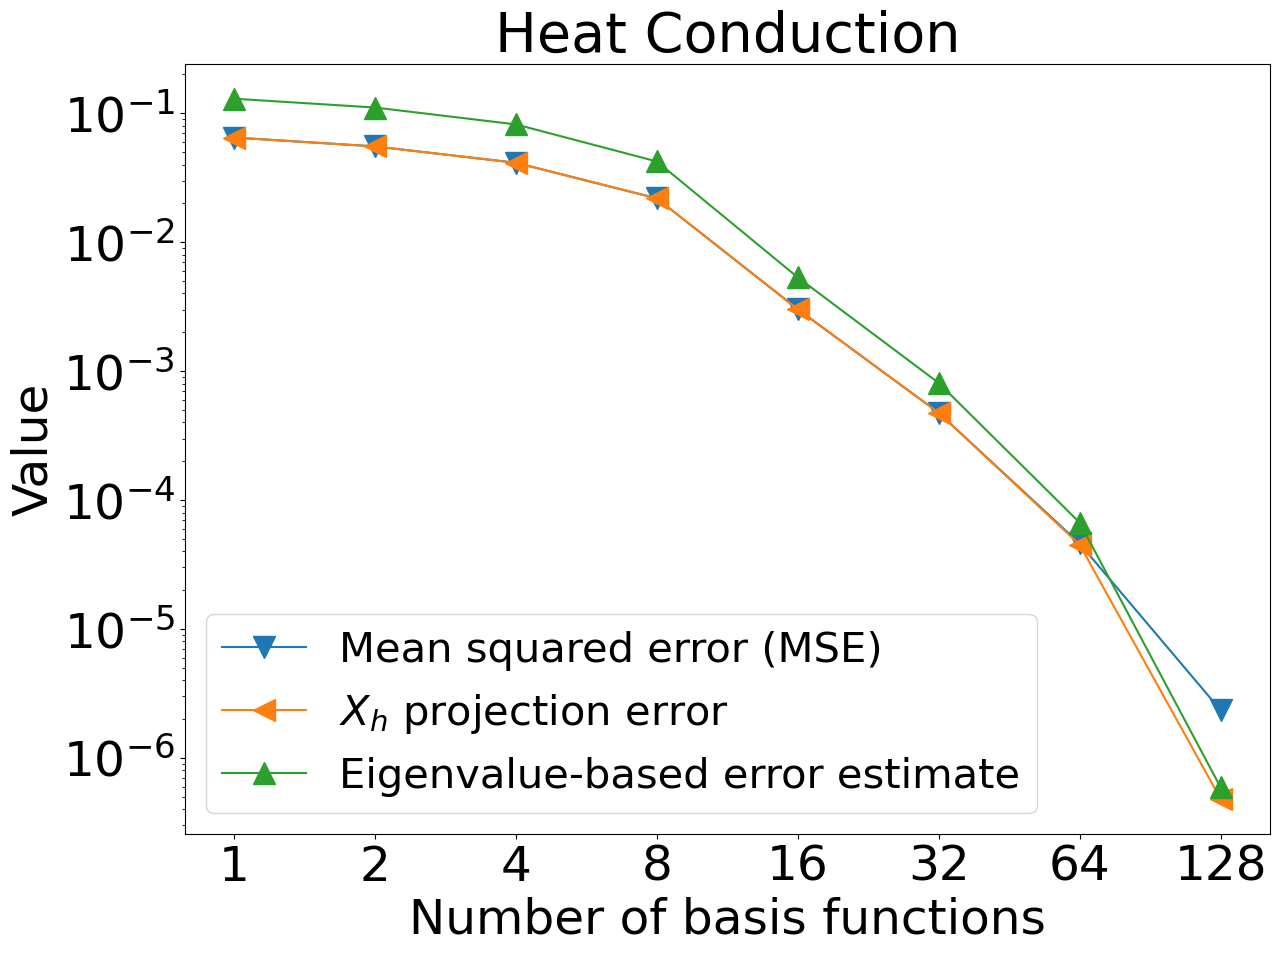

In [20]:
plt.figure(figsize=(14,10))
plt.plot(num_basis_list, mean_reduced_basis_mse_error_record, marker='v', markersize=16, label='Mean squared error (MSE)')
plt.plot(num_basis_list, mean_Xh_projection_error_record, marker='<',  markersize=16, label=r'$X_h$ projection error')
plt.plot(num_basis_list, error_estimate_by_trailing_eigenvalues_list, marker='^', markersize=16, label='Eigenvalue-based error estimate')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of basis functions', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_basis_list, num_basis_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=30, loc='lower left')
plt.title('Heat Conduction', fontsize=40)
plt.savefig(os.path.join(test_dataset_path, "analysis_error_compared_to_RT1xCG2_solution.png"), dpi=300, bbox_inches='tight')
plt.show()